# **Step2. 상품리뷰분석 Agent2**

## **0. 미션**

### 미션③ : LangSmith 기반 모니터링 시스템 구축
* [필수] 실행 Trace : 설정 및 관측 결과 확인
* [선택항목] 다음 항목은 예시 입니다.
	* 평가 : 데이터셋 구성, 평가 지표 설정 및 확인
	* 실패(혹은 오류) 케이스를 만들고 추적 및 원인 분석


### 미션④ : Agent 고도화
* [필수] Supervisor 중심 반복 제어
* [필수] DB에 쌓인 리뷰 예측 batch 처리
* [선택항목] 다음은 예시 입니다.
    - 각 에이전트 고도화 : 성능/정확도를 높이기 위한 프롬프트 개선 등
    - HITL 노드 설계 : 특정 조건 시 Human Review 전환
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### 미션⑤ : 대시보드 만들기(streamlit 기반)
* [필수] 기본 대시보드 : 리뷰 결과 집계 및 개별 정보 조회
* [선택항목] 다음은 예시 입니다.
    - 감성분석 결과에 대한 다양한 시각화
    -  Insight Agent 추가 : 요약 리포트 생성 및 개선 제안 도출
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### 워크플로우 V2.0

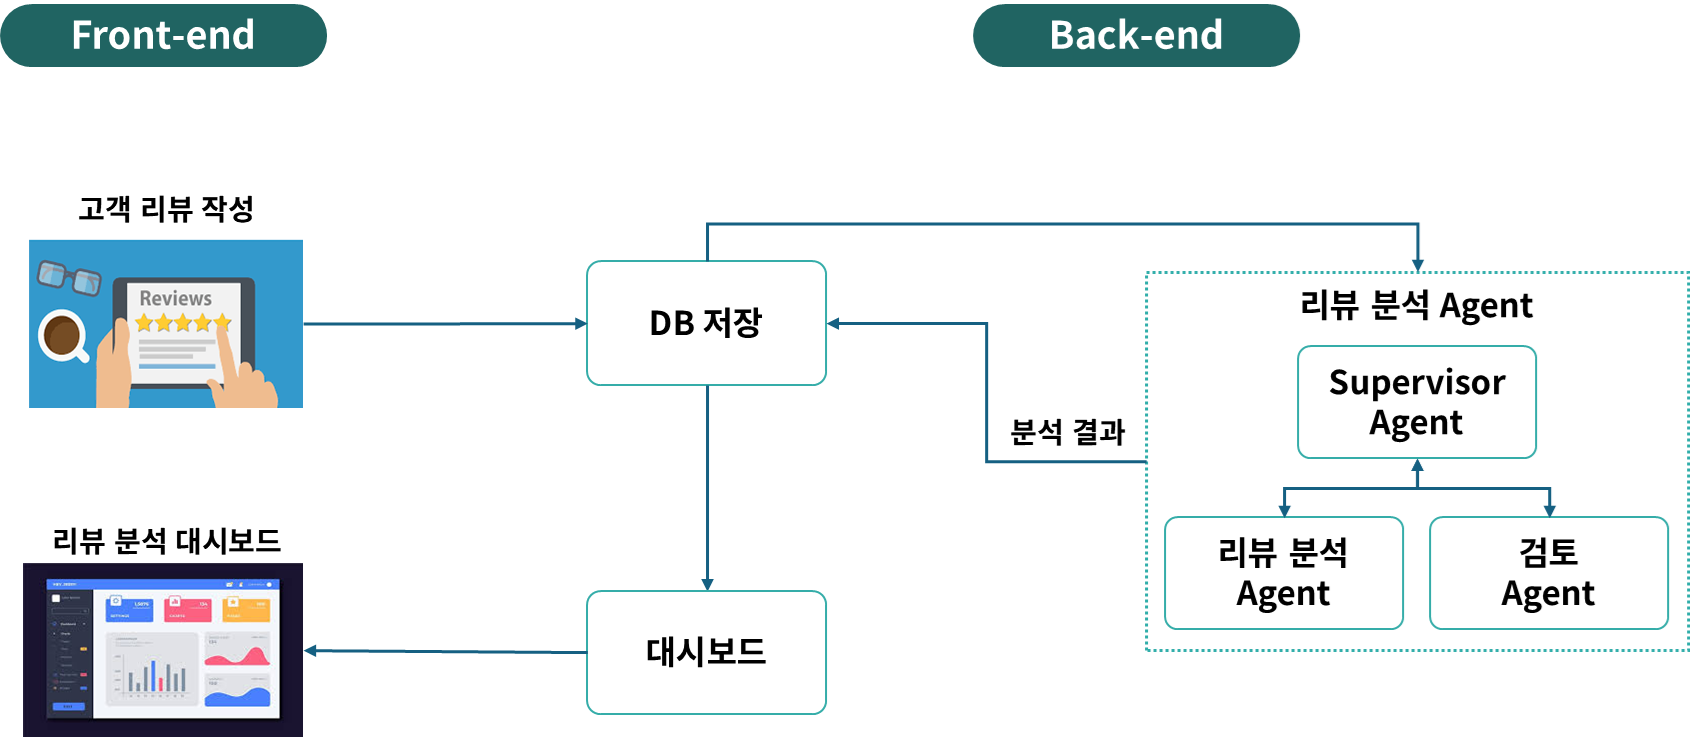

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `proj2_agent`를 생성(이미 만들었다면 skip)
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 라이브러리

* 필요한 라이브러리 설치

In [ ]:
!pip install -q langchain-openai langchain-community streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


* 라이브러리 로딩

In [ ]:
# 기본 제공 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import os
import openai
import ast
import re

from typing import TypedDict, Annotated, List, Optional, Literal, Dict, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI

# 더 필요한 라이브러리가 있다면 추가합시다. -----




### (3) OpenAI API Key 확인

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/proj2_agent/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

In [ ]:
print(os.environ['OPENAI_API_KEY'][:30])

sk-6HnpTor5FDdHd3WXGaRUshfzSdb


## **2. 미션③ : langsmith 기반 운영 시스템**

* [필수] 실행 Trace : 설정 및 관측 결과 확인
* [선택항목] 다음 항목은 예시 입니다.
	* 평가 : 데이터셋 구성, 평가 지표 설정 및 확인
	* 실패(혹은 오류) 케이스를 만들고 추적 및 원인 분석

### **(1) langsmith 설정**

* langsmith trace에 project 추가 : `proj2_agent`


* 운영환경 설정

In [ ]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "proj2_agent"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

### **(2) Step1 결과물**
* Step1의 결과물을 아래 붙여 넣습니다.

#### **1) State & LLM 준비**

In [ ]:
class ReviewState(TypedDict):
    # 입력 리뷰
    review: str

    # 개별 에이전트 실행 결과
    analyzer_result: Optional[Dict[str, Any]]   # {"items":[{"aspect":..., "label":..., "evidence":...}, ...]}
    critic_result: Optional[Dict[str, Any]]     # {"verdict":"적합|부적합", "reasons":"..."}

    # 흐름 제어
    retry_count: int
    max_retries: int
    next_agent: Literal["analyzer", "critic", "end"]

* llm 준비

In [ ]:
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)

#### **2) Agent 노드 준비**
* 필요 Agent : Analyzer Agent, Critic Agent, Supervisor Agent
* 리뷰 결과 State에 담기게 되는 형식 : Dictionary(혹은 JSON)


* Analyzer Agent

In [ ]:
def analyzer_node(state: ReviewState):
    review = state["review"]

    sys_msg = """# 역할 : 너는 상품 리뷰 분석 Agent.
# 목표 : 리뷰에서 언급된 속성만 추출하여 감성(긍정=1, 부정=0)을 판정.
# 속성 목록(이 4개만 허용): 보습, 가격, 향, 포장
# 규칙:
- 속성은 언급된 것만 포함한다. 없으면 items는 빈 리스트로 작성한다.
- label은 0 또는 1만 사용한다.
- 같은 속성(aspect)은 반드시 한 번만 출력한다. 리뷰에 같은 속성이 여러 번 등장해도 하나로 통합한다.
- evidence는 해당 속성을 가장 잘 보여주는 대표 근거 1개만 작성한다.
- 출력은 오직 딕셔너리 1개만 작성한다.
- 설명, 코드블록, 마크다운은 포함하지 않는다.
# 출력 구조 예시:
{"items": [
    {"aspect": "가격", "label": 0, "evidence": "가격이 조금 비싸요"},
    {"aspect": "포장", "label": 1, "evidence": "포장이 깔끔했어요"}
]}
"""
    human_msg = f"""다음 리뷰에 대해 상품 감성 분석 수행해.
- 리뷰 : {review}
"""

    response = llm.invoke([SystemMessage(content=sys_msg),
                      HumanMessage(content=human_msg)])
    parsed = ast.literal_eval(response.content) # 문자열을 딕셔너리로 변환

    return {"analyzer_result": parsed}

* Critic Agent

In [ ]:
def critic_node(state: ReviewState):
    review = state["review"]
    result = state.get("analyzer_result", {"items": []})

    sys_msg = """# 역할 : 너는 리뷰 분석 결과에 대한 검수 Agent.
# 목표 : 아래 분석 결과가 리뷰에 대한 분석결과에 대해 '적합', '부적합'으로 판단.
# 판단 기준
- '적합' : 분석 결과가 리뷰 내용과 일치하고, 근거(evidence)가 리뷰에서 확인 가능
- '부적합' : 리뷰에 없는 내용을 추론/추가했거나, 속성/감성 판단이 리뷰와 어긋남.
- 판단이 애매하면 '부적합'으로 보수적 판정
# 출력은 오직 Dictionary 1개만:
- verdict : 반드시 둘 중 하나만 : '적합', '부적합'
- reason : 판단 이유에 대해 짧게 핵심만 작성
- 출력 예시
{"verdict":"적합","reason":"이유..."}
"""
    human_msg = f"""주어진 리뷰와 분석 결과를 바탕으로 판단.
# 리뷰: {review}
# 분석 결과: {result}
"""

    response = llm.invoke([SystemMessage(content=sys_msg),
                      HumanMessage(content=human_msg)])

    parsed = ast.literal_eval(response.content)

    return {"critic_result": parsed}

* Supervisor Agent

In [ ]:
def supervisor_node(state: ReviewState):
    if state.get("analyzer_result") is None:
        return {"next_agent": "analyzer"}

    if state.get("critic_result") is None:
        return {"next_agent": "critic"}

    verdict = state["critic_result"].get("verdict", "부적합")

    if verdict == "적합":
        return {"next_agent": "end"}

    retry = state.get("retry_count", 0)
    max_r = state.get("max_retries", 1)

    if retry >= max_r:
        return {"next_agent": "end"}

    return {
        "next_agent": "analyzer",
        "retry_count": retry + 1,
        "critic_result": None,
        "analyzer_result": None
    }

#### **3) 그래프 구성**

* route_next 함수

In [ ]:
def route_next(state: ReviewState) -> str:
    return state["next_agent"]

* 그래프

In [ ]:
graph = StateGraph(ReviewState)

graph.add_node("supervisor", supervisor_node)
graph.add_node("analyzer", analyzer_node)
graph.add_node("critic", critic_node)

graph.set_entry_point("supervisor")

# Worker는 항상 Supervisor로 반환
graph.add_edge("analyzer", "supervisor")
graph.add_edge("critic", "supervisor")

# Supervisor만 라우팅
graph.add_conditional_edges(
    "supervisor",
    route_next,
    {
        "analyzer": "analyzer",
        "critic": "critic",
        "end": END
    }
)

app = graph.compile()

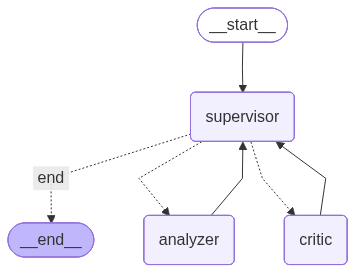

In [ ]:
app

### **(3) 추적 확인**

예제 코드를 통해 추적을 확인해 봅시다.


In [ ]:
review = '''
잘 사용하고 있어요. 보습력도 좋고 향도 좋아서 잘 사용합니다.
용량도 커서 부담없이 자주 바르고 있어요.
앞으로도 잘 사용할 것 같아요. 보습력 향 모두 만족하는 상품입니다.
'''

init_state: ReviewState = {
        "review": review,
        "analyzer_result": None,
        "critic_result": None,
        "retry_count": 0,
        "max_retries": 2,
        "next_agent": "analyzer",
    }

result = app.invoke(init_state)
result

{'review': '\n잘 사용하고 있어요. 보습력도 좋고 향도 좋아서 잘 사용합니다.\n용량도 커서 부담없이 자주 바르고 있어요.\n앞으로도 잘 사용할 것 같아요. 보습력 향 모두 만족하는 상품입니다.\n',
 'analyzer_result': {'items': [{'aspect': '보습',
    'label': 1,
    'evidence': '보습력도 좋고'},
   {'aspect': '향', 'label': 1, 'evidence': '향도 좋아서'}]},
 'critic_result': {'verdict': '적합',
  'reason': '분석 결과의 긍정적 보습과 향 평가가 리뷰 내용과 일치하며, 근거 문구가 리뷰에 명확히 존재함'},
 'retry_count': 0,
 'max_retries': 2,
 'next_agent': 'end'}

## **3. 미션④ : Agent 고도화**

* [필수] Supervisor 중심 반복 제어
    - LLM 기반 흐름 제어
    - reason_code 기반 재시도 정책
* [필수] DB에 쌓인 리뷰 예측 batch 처리
* [선택항목] 다음은 예시 입니다.
    - 각 에이전트 고도화 : 성능/정확도를 높이기 위한 프롬프트 개선 등
    - HITL 노드 설계 : 특정 조건 시 Human Review 전환
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### **(1) Supervisor 중심 반복 제어**

* Supervisor Agent : 통제 정책 오케스트레이터(Policy Orchestrator)
    * Critic 판정이 ‘부적합’ 일 때 LLM은
        * critic_reason을 확인하여 reason_code 분류
        * 재시도 시 필요한 짧은 수정 지시를 repair_directive에 저장


#### **1) State 보완**

In [ ]:
ReasonCode = Literal["OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"]

class ReviewState(TypedDict):
    review: str

    analyzer_result: Optional[Dict[str, Any]]
    critic_result: Optional[Dict[str, Any]]   # {"verdict":"적합|부적합","reason":"..."}

    # Step2 추가(필수)
    reason_code: Optional[ReasonCode]
    repair_directive: Optional[str]

    retry_count: int
    max_retries: int
    next_agent: Literal["analyzer", "critic", "end"]

In [ ]:
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)

#### **2) Agent 노드 준비**

In [ ]:
# 정책 및 필요 함수 준비 : 아래 내용을 수정해서 사용하세요.

REASON_CODES = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"}
RETRYABLE = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR"}

REPAIR_TEMPLATES = {
    "OUTPUT_ERROR": "dict 1개만 출력. 코드블록/설명 없이 items 구조와 label(0/1)을 맞춰라.",
    "SCOPE_ERROR": "aspect는 보습, 가격, 향, 포장만 사용하라. 다른 표현은 가장 가까운 값으로 매핑하라.",
    "EVIDENCE_ERROR": "evidence는 리뷰 원문에 실제로 있는 연속된 문구만 사용하라.",
    "QUALITY_ERROR": "리뷰에 없는 내용을 만들지 말고, 애매하면 해당 aspect는 제외하라."
}

# 딕셔너리 파싱 함
def parse_dict(text, default):
    try:
        return ast.literal_eval(text)
    except:
        return default

* Analyzer Agents 보완

In [ ]:
def analyzer_node(state: ReviewState):
    review = state["review"]
    repair = (state.get("repair_directive") or "").strip()

    sys_msg = """# 역할 : 너는 상품 리뷰 분석 Agent.
# 목표 : 리뷰에서 언급된 속성만 추출하여 감성(긍정=1, 부정=0)을 판정한다.
# 허용 속성 : 보습, 가격, 향, 포장

# 규칙
- 언급된 속성만 포함한다.
- 없으면 items는 빈 리스트로 작성한다.
- label은 0 또는 1만 사용한다.
- 같은 aspect는 한 번만 출력한다.
- evidence는 해당 속성을 가장 잘 보여주는 대표 근거 1개만 작성한다.
- 출력은 파이썬 dict 1개만 작성한다.
- 설명, 코드블록, 마크다운은 금지한다.

# 출력 예시
{"items": [{"aspect": "가격", "label": 0, "evidence": "가격이 조금 비싸요"},
           {"aspect": "포장", "label": 1, "evidence": "포장이 깔끔했어요"}]}
"""

    human_msg = f"""다음 리뷰를 분석하라.
- 리뷰: {review}
- 추가 수정 지시: {repair}
"""

    response = llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=human_msg)
    ])

    parsed = parse_dict(response.content, {"items": []})
    return {"analyzer_result": parsed}

* Critic Agent 보완

In [ ]:
def critic_node(state: ReviewState):
    review = state["review"]
    result = state.get("analyzer_result") or {"items": []}

    sys_msg = """# 역할 : 너는 리뷰 분석 결과를 검수하는 Critic Agent.
# 목표 : 분석 결과를 '적합' 또는 '부적합'으로 판정한다.

# 판단 기준
- 적합: 리뷰 내용과 일치하고, evidence가 리뷰에서 확인 가능
- 부적합: 리뷰에 없는 내용을 추가했거나, aspect/label/evidence가 부정확함
- 애매하면 부적합으로 판단한다.

# 규칙
- 출력은 파이썬 dict 1개만 작성한다.
- verdict는 반드시 '적합' 또는 '부적합' 중 하나만 쓴다.
- reason은 짧고 핵심만 작성한다.
- 설명, 코드블록, 마크다운은 금지한다.

# 출력 예시
{"verdict": "적합", "reason": "리뷰 내용과 근거가 일치함"}
"""

    human_msg = f"""주어진 리뷰와 분석 결과를 보고 판정하라.
# 리뷰
{review}

# 분석 결과
{result}
"""

    response = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])
    parsed = parse_dict(response.content, {"verdict": "부적합", "reason": "출력 형식 오류"})

    return {"critic_result": parsed}

* Supervisor Agent 보완

In [ ]:
def supervisor_node(state: ReviewState):
    # 실행 순서
    if state.get("analyzer_result") is None:
        return {"next_agent": "analyzer"}

    if state.get("critic_result") is None:
        return {"next_agent": "critic"}

    critic = state["critic_result"] or {}
    verdict = (critic.get("verdict") or "부적합").strip()
    reason = (critic.get("reason") or "").strip()

    # 적합이면 종료
    if verdict == "적합":
        return {"reason_code": "OK",
                "repair_directive": "",
                "next_agent": "end"
        }

    retry = int(state.get("retry_count", 0))
    max_r = int(state.get("max_retries", 1))

    sys_msg = """
# 역할 : 너는 Supervisor 판단 Agent

# 작업
critic의 판정 사유를 보고 아래 reason_code 중 하나만 선택한다.
- OUTPUT_ERROR
- SCOPE_ERROR
- EVIDENCE_ERROR
- QUALITY_ERROR

# 분류 기준
- OUTPUT_ERROR: 출력 형식, items 구조, label 범위 등 형식 문제
- SCOPE_ERROR: 허용되지 않은 aspect 사용
- EVIDENCE_ERROR: evidence가 리뷰 원문과 맞지 않음
- QUALITY_ERROR: 그 외 품질 문제

# 규칙
- 반드시 1개만 선택한다.
- 가장 직접적인 원인 1개만 고른다.
- 애매하면 QUALITY_ERROR로 분류한다.
- 출력은 파이썬 dict 1개만 작성한다.
- 설명, 코드블록, 마크다운은 금지한다.

# 출력 예시
{"reason_code":"OUTPUT_ERROR", "repair_directive":"dict 형식과 items 구조를 맞춰라."}
"""

    human_msg = f"""critic_reason:
{reason}
"""

    response = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])
    decision = parse_dict(response.content, {"reason_code": "QUALITY_ERROR", "repair_directive": ""})

    reason_code = (decision.get("reason_code") or "").strip().upper()
    if reason_code not in REASON_CODES:
        reason_code = "QUALITY_ERROR"

    repair = (decision.get("repair_directive") or "").strip()
    if not repair:
        repair = REPAIR_TEMPLATES.get(reason_code, "")

    # 재시도 가능한 오류면 analyzer로 재진입
    if reason_code in RETRYABLE and retry < max_r:
        return {
            "reason_code": reason_code,
            "repair_directive": repair,
            "next_agent": "analyzer",
            "retry_count": retry + 1,
            "analyzer_result": None,
            "critic_result": None
        }

    # 재시도 불가 or 최대 재시도 도달 시 종료
    return {"reason_code": reason_code, "repair_directive": repair, "next_agent": "end"}

* route_next 함수

In [ ]:
def route_next(state: ReviewState) -> str:
    return state["next_agent"]

* 그래프

In [ ]:
graph2 = StateGraph(ReviewState)

graph2.add_node("supervisor", supervisor_node)
graph2.add_node("analyzer", analyzer_node)
graph2.add_node("critic", critic_node)

graph2.set_entry_point("supervisor")

graph2.add_edge("analyzer", "supervisor")
graph2.add_edge("critic", "supervisor")

graph2.add_conditional_edges(
    "supervisor",
    route_next,
    {"analyzer": "analyzer", "critic": "critic", "end": END}
)

app = graph2.compile()

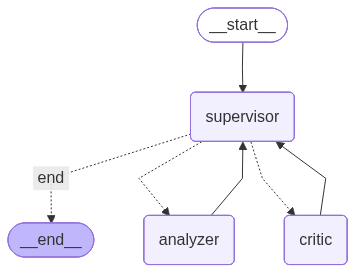

In [ ]:
app

* 실행 테스트

In [ ]:
review = '''
잘 사용하고 있어요. 보습력도 좋고 향도 좋아서 잘 사용합니다.
용량도 커서 부담없이 자주 바르고 있어요.
앞으로도 잘 사용할 것 같아요. 보습력 향 모두 만족하는 상품입니다.
'''

init: ReviewState = {
        "review": review,
        "analyzer_result": None,
        "critic_result": None,
        "retry_count": 0,
        "max_retries": 2,
        "next_agent": "analyzer",
    }

result = app.invoke(init)
print(result)

{'review': '\n잘 사용하고 있어요. 보습력도 좋고 향도 좋아서 잘 사용합니다.\n용량도 커서 부담없이 자주 바르고 있어요.\n앞으로도 잘 사용할 것 같아요. 보습력 향 모두 만족하는 상품입니다.\n', 'analyzer_result': {'items': [{'aspect': '보습', 'label': 1, 'evidence': '보습력도 좋고 향도 좋아서 잘 사용합니다.'}, {'aspect': '향', 'label': 1, 'evidence': '보습력도 좋고 향도 좋아서 잘 사용합니다.'}]}, 'critic_result': {'verdict': '적합', 'reason': '보습과 향에 대해 긍정적으로 언급한 부분이 근거로 명확히 제시됨'}, 'reason_code': 'OK', 'repair_directive': '', 'retry_count': 0, 'max_retries': 2, 'next_agent': 'end'}


### **(2) DB에 쌓인 리뷰 예측 batch 처리**

* 리뷰 데이터 여러 건을 임의로 생성하여 Step1에서 생성한 DB의 테이블에 저장.
* DB에서 분석 대상 리뷰 조회(예: agent_aspect가 NULL인 데이터)
* 각 리뷰에 대해 Agent 실행
* 분석 결과(items)에서 aspect , label 추출
* DB에 결과 저장 (UPDATE)


#### **1) 데이터 준비**
* data.csv 파일 로딩
* review 칼럼의 값만 DB에 저장

In [ ]:
# 코랩에 파일 업로드
from google.colab import files
uploaded = files.upload()

In [ ]:
data = pd.read_csv("data.csv")
data.head()

,review,aspect,label
0,연령상관없이 요즘 너무 인기 있어서 한번 사봤습니다. 도대체 얼마나 좋길래 다들 O...,['가격'],[0]
1,구매후 3일정도 사용하고 후기 작성하는데요. 최근 들어 탈모가 심해지는것 같아서 탈...,['향'],[1]
2,친구랑 같이 기숙사에 사는데 어느 날 친구가 이 향수를 사 왔더라구요?? 향이 어떨...,['향'],[1]
3,써보고 주위 선물 하려고 샀어요. 눈 주위에 바르고 있는데 덜 건조하고 촉촉해요 휴...,['보습'],[1]
4,택배 잘 받았어요. 처음으로 주문해서 써봤는데 발림성이 부드러워서 좋고 용량이 많아...,"['가격', '포장']","[1, 1]"


In [ ]:
# Step1에서 만든 DB 그대로 사용
conn = sqlite3.connect(path + "reviews.db")
cur = conn.cursor()

sample_reviews = list(data['review'])

insert_sql = """
INSERT INTO absa_reviews (review, agent_aspect, agent_label, updated_at)
VALUES (?, NULL, NULL, datetime('now'))
"""

for review in sample_reviews:
    cur.execute(insert_sql, (review,))

conn.commit()

#### **2) 리뷰를 읽어서 Agent 실행후 결과 저장**

In [ ]:
# 함수 생성

# 1) 미처리 리뷰 조회 함수
def fetch_pending_reviews(conn, limit=100):
    query = """
    SELECT id, review
    FROM absa_reviews
    WHERE agent_aspect IS NULL
    ORDER BY id
    LIMIT ?
    """
    cur = conn.cursor()
    cur.execute(query, (limit,))
    rows = cur.fetchall()

    return [{"id": r[0], "review": r[1]} for r in rows]

# 2) Agent 결과에서 aspect, label 추출 함수
def extract_aspect_label_from_result(result: dict):
    items = result.get("analyzer_result", {}).get("items", [])

    agent_aspect = [item["aspect"] for item in items]
    agent_label = [item["label"] for item in items]

    return agent_aspect, agent_label

# 3) DB 업데이트
def update_review_result(conn, row_id: int, agent_aspect: list, agent_label: list):
    update_sql = """
    UPDATE absa_reviews
    SET agent_aspect = ?, agent_label = ?, updated_at = datetime('now')
    WHERE id = ?
    """

    cur = conn.cursor()
    cur.execute(update_sql,
                    (json.dumps(agent_aspect, ensure_ascii=False),
                     json.dumps(agent_label, ensure_ascii=False),
                     row_id)
    )
    conn.commit()

# 4) batch 실행
def run_batch_reviews(conn, limit=100, max_retries=2, verbose=True):
    rows = fetch_pending_reviews(conn, limit=limit)

    if verbose:
        print(f"처리 대상 리뷰 수: {len(rows)}")

    for row in rows:
        row_id = row["id"]
        review = row["review"]

        init_state: ReviewState = {
            "review": review,
            "analyzer_result": None,
            "critic_result": None,
            "reason_code": None,
            "repair_directive": None,
            "retry_count": 0,
            "max_retries": max_retries,
            "next_agent": "analyzer",
        }

        try:
            result = app.invoke(init_state)

            agent_aspect, agent_label = extract_aspect_label_from_result(result)
            update_review_result(conn, row_id, agent_aspect, agent_label)

            if verbose:
                print(f"[완료] id={row_id} / aspect={agent_aspect} / label={agent_label}")

        except Exception as e:
            if verbose:
                print(f"[오류] id={row_id} / {e}")

In [ ]:
# 배치 실행
run_batch_reviews(conn, limit=100, max_retries=2, verbose=True)

# 실행 결과 확인
df = pd.read_sql_query("""
SELECT id, review, agent_aspect, agent_label, updated_at
FROM absa_reviews
ORDER BY id
""", conn)

df

처리 대상 리뷰 수: 10
[완료] id=6 / aspect=['가격'] / label=[0]
[완료] id=7 / aspect=['향'] / label=[1]
[완료] id=8 / aspect=['향'] / label=[1]
[완료] id=9 / aspect=['보습'] / label=[1]
[완료] id=10 / aspect=['가격'] / label=[1]
[완료] id=11 / aspect=[] / label=[]
[완료] id=12 / aspect=['향'] / label=[1]
[완료] id=13 / aspect=['가격'] / label=[1]
[완료] id=14 / aspect=['향', '가격'] / label=[1, 1]
[완료] id=15 / aspect=['향', '보습'] / label=[1, 1]


,id,review,agent_aspect,agent_label,updated_at
0,1,보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요.,"[""보습"", ""향"", ""가격""]","[1, 1, 0]",2026-04-03 04:56:56
1,2,보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요.,"[""보습"", ""향"", ""가격""]","[1, 1, 0]",2026-04-03 05:04:28
2,3,\n잘 사용하고 있어요. 보습력도 좋고 향도 좋아서 잘 사용합니다.\n용량도 커서 ...,"['보습', '향']","[1, 1]",2026-04-03 05:48:05
3,4,잘 사용하고 있어요. 보습력도 좋고 향도 좋아서 잘 사용합니다.\n용량도 커서 부담...,"['보습', '향']","[1, 1]",2026-04-03 06:19:13
4,5,"촉촉하고 좋은데, 양이 좀 부족해요.",['보습'],[1],2026-04-03 06:22:39
...,...,...,...,...,...
200,201,피부 좋은 직장후배의 추천으로 알게 된 OO OOO 크림팩!!! 이제품을 쓰고 나의...,None,None,2026-04-09 02:28:22
201,202,향수 필요해서 찾아 보다가 이 제품 할인 해서 구매하게 되었는데 품질이 생각보다 좋...,None,None,2026-04-09 02:28:22
202,203,시원하다길래 반신반의하면서 구매했어요 엄청 시원한건아니지만 그래도 시원한감은 있어요...,None,None,2026-04-09 02:28:22
203,204,꾸준히 애용하고 있습니다. 사용기한도 넉넉합니다. 특히 향이 은은하여 좋네요. 보습...,None,None,2026-04-09 02:28:22


## **4. 미션⑤ : 대시보드 만들기**

### (1) 한글 폰트 준비

* 한글폰트 설치

In [ ]:
!apt-get -y install fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


* 세션 다시시작

### **(2) 대시보드 앱 : app.py**

* 최소 요구사항
    * 프레임1 : 상품리뷰 결과를 분석하는 그래프
    * 프레임2 : 리뷰 분석 결과 건별 조회


In [ ]:
%%writefile app.py
import json
import sqlite3
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns

# 한글 폰트 세팅 -------------------------------
def set_korean_font():
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()

    mpl.rcParams["font.family"] = font_name
    mpl.rcParams["axes.unicode_minus"] = False

    sns.set_theme(style="whitegrid", rc={
        "font.family": font_name,
        "axes.unicode_minus": False
    })

    return fm.FontProperties(fname=font_path)

font_prop = set_korean_font()


# -----------------------------
# 1. 함수, 데이터 준비
# -----------------------------

db_path = '/content/drive/MyDrive/proj2_agent/reviews.db'

# json 변환 함수
def safe_load_json_list(x):
    if x is None:
        return []
    s = str(x).strip()
    if s == "" or s.lower() in ("none", "null"):
        return []
    try:
        return json.loads(s)
    except Exception:
        return []

# 데이터 준비
@st.cache_data
def load_df(db_path: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("""
        SELECT id, review, agent_aspect, agent_label, updated_at
        FROM absa_reviews where agent_aspect is not null
        ORDER BY id
    """, conn)
    conn.close()

    df["agent_aspect_list"] = df["agent_aspect"].apply(safe_load_json_list)
    df["agent_label_list"] = df["agent_label"].apply(safe_load_json_list)

    return df


def build_sentiment_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in df.iterrows():
        aspects = row["agent_aspect_list"]
        labels = row["agent_label_list"]

        for a, l in zip(aspects, labels):
            rows.append({
                "aspect": a,
                "label": int(l)
            })

    if not rows:
        return pd.DataFrame(columns=["aspect", "긍정", "부정"])

    temp = pd.DataFrame(rows)
    temp["sentiment"] = temp["label"].map({1: "긍정", 0: "부정"})

    result = (
        temp.groupby(["aspect", "sentiment"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    if "긍정" not in result.columns:
        result["긍정"] = 0
    if "부정" not in result.columns:
        result["부정"] = 0

    return result[["aspect", "긍정", "부정"]]


st.set_page_config(page_title="상품 리뷰 분석 대시보드", layout="wide")
st.title("상품 리뷰 분석 대시보드 (Step2)")

df = load_df(db_path)

# -----------------------------
# 2. Streamlit UI
# -----------------------------

# 기본 현황
total_count = len(df)
done_count = df["agent_aspect"].notna().sum()
pending_count = total_count - done_count

c1, c2, c3 = st.columns(3)
c1.metric("총 리뷰 수", total_count)
c2.metric("분석 완료", done_count)
c3.metric("미처리", pending_count)

st.divider()


# 프레임1: 결과 집계
st.subheader("리뷰 분석 결과 집계")

sentiment_df = build_sentiment_table(df)

if sentiment_df.empty:
    st.info("집계할 분석 결과가 없습니다.")
else:
    st.dataframe(sentiment_df, use_container_width=True, hide_index=True)

    plot_df = sentiment_df.melt(id_vars="aspect", value_vars=["긍정", "부정"],
                                var_name="sentiment", value_name="count")

    fig, ax = plt.subplots(figsize=(8, 4))

    sns.barplot(data=plot_df, x="aspect", y="count", hue="sentiment",
        palette=["#4A90E2", "#A7C7E7"], ax=ax )

    ax.set_title("속성별 감성 분석", fontproperties=font_prop)
    ax.set_xlabel("속성", fontproperties=font_prop)
    ax.set_ylabel("건수", fontproperties=font_prop)

    for label in ax.get_xticklabels():
        label.set_fontproperties(font_prop)
    for label in ax.get_yticklabels():
        label.set_fontproperties(font_prop)

    legend = ax.legend(title="감성", prop=font_prop)
    legend.get_title().set_fontproperties(font_prop)

    st.pyplot(fig)
    plt.close(fig)

st.divider()

# 프레임2: 건별 조회
st.subheader("리뷰 분석 결과 건별 조회")

if df.empty:
    st.warning("DB에 저장된 리뷰가 없습니다.")
else:
    selected_id = st.selectbox("조회할 id 선택", df["id"].tolist())
    row = df[df["id"] == selected_id].iloc[0]

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**리뷰 원문**")
        st.write(row["review"])
        st.markdown("**업데이트 시각**")
        st.write(row["updated_at"])

    with col2:
        st.markdown("**예측 결과**")
        aspects = row["agent_aspect_list"]
        labels = row["agent_label_list"]

        if aspects and labels:
            result_df = pd.DataFrame({
                "aspect": aspects,
                "label": ["긍정" if int(x) == 1 else "부정" for x in labels]
            })
            st.dataframe(result_df, use_container_width=True, hide_index=True)
        else:
            st.info("예측 결과가 없습니다.")

Overwriting app.py


### (3) 스트림릿 실행

* Streamlit 실행 + 외부 URL 열기
    - Cloudflare tunnel로 외부 링크 생성
    - Streamlit (재)시작 (localhost로 붙이기)
    - 외부 URL 생성 및 접속

* Cloudflare tunnel로 외부 링크 생성

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

(Reading database ... 118198 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) over (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...


* Streamlit (재)시작 (localhost로 붙이기)

In [ ]:
!pkill -9 -f streamlit || true
!pkill -9 -f cloudflared || true
!rm -f streamlit.log cloudflared.log

!streamlit run app.py \
  --server.port 8501 \
  --server.address 127.0.0.1 \
  --server.headless true \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > streamlit.log 2>&1 &

^C
^C


* 외부 URL 생성 및 접속

In [ ]:
!cloudflared tunnel --url http://127.0.0.1:8501

* 주소 링크를 복사해서, 구글크롬브라우저 > 새 시크릿 창 주소에 복사해서 스트림릿 화면을 띄웁니다.